In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = {
    "Rainfall": [20, 35, 50, 70, 90, 110, 130, 150, 25, 45,
                 65, 85, 105, 125, 145, 30, 55, 75, 95, 115,
                 135, 155, 40, 60, 80, 100, 120, 140, 160, 180],

    "Temperature": [32, 31, 30, 29, 28, 27, 26, 25, 33, 32,
                     31, 30, 29, 28, 27, 33, 32, 31, 30, 29,
                     28, 27, 32, 31, 30, 29, 28, 27, 26, 25],

    "Humidity": [45, 50, 55, 60, 65, 70, 75, 80, 48, 53,
                 58, 63, 68, 73, 78, 47, 57, 62, 67, 72,
                 77, 82, 52, 59, 64, 69, 74, 79, 84, 88],

    "Water_Level": [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.5,
                    1.1, 1.3, 1.5, 1.7, 1.9, 2.1, 2.4,
                    1.2, 1.4, 1.6, 1.8, 2.0, 2.3, 2.6,
                    1.3, 1.5, 1.7, 1.9, 2.2, 2.5, 2.8, 3.0],

    "Soil_Moisture": [20, 25, 30, 35, 40, 45, 50, 55, 22, 28,
                      33, 38, 43, 48, 53, 24, 31, 36, 41, 46,
                      51, 57, 27, 34, 39, 44, 49, 54, 59, 65],

    "Wind_Speed": [5, 6, 7, 8, 9, 10, 11, 12, 5, 7,
                   8, 9, 10, 11, 12, 6, 7, 8, 9, 10,
                   11, 13, 6, 8, 9, 10, 12, 13, 14, 15],

    "Flood_Risk": ["Low", "Low", "Low", "Medium", "Medium",
                   "Medium", "High", "High", "Low", "Low",
                   "Medium", "Medium", "Medium", "High", "High",
                   "Low", "Low", "Medium", "Medium", "Medium",
                   "High", "High", "Low", "Medium", "Medium",
                   "Medium", "High", "High", "High", "High"]
}

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (30, 7)


,Rainfall,Temperature,Humidity,Water_Level,Soil_Moisture,Wind_Speed,Flood_Risk
0,20,32,45,1.0,20,5,Low
1,35,31,50,1.2,25,6,Low
2,50,30,55,1.4,30,7,Low
3,70,29,60,1.6,35,8,Medium
4,90,28,65,1.8,40,9,Medium


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rainfall       30 non-null     int64  
 1   Temperature    30 non-null     int64  
 2   Humidity       30 non-null     int64  
 3   Water_Level    30 non-null     float64
 4   Soil_Moisture  30 non-null     int64  
 5   Wind_Speed     30 non-null     int64  
 6   Flood_Risk     30 non-null     object 
dtypes: float64(1), int64(5), object(1)
memory usage: 1.8+ KB
None


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Rainfall         0
Temperature      0
Humidity         0
Water_Level      0
Soil_Moisture    0
Wind_Speed       0
Flood_Risk       0
dtype: int64


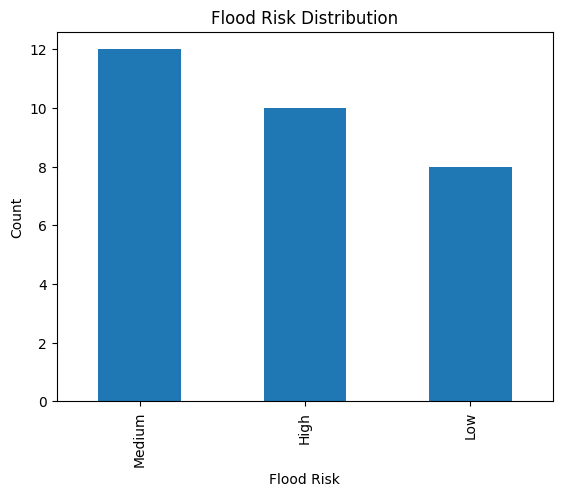

In [ ]:
df["Flood_Risk"].value_counts().plot(kind="bar")

plt.xlabel("Flood Risk")
plt.ylabel("Count")
plt.title("Flood Risk Distribution")
plt.show()

In [ ]:
X = df[[
    "Rainfall",
    "Temperature",
    "Humidity",
    "Water_Level",
    "Soil_Moisture",
    "Wind_Speed"
]]

y = df["Flood_Risk"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24, 6)
Testing Data: (6, 6)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
y_pred = model.predict(X_test_scaled)

print("Predicted Values:")
print(y_pred)

Predicted Values:
['Medium' 'Medium' 'Medium' 'High' 'Low' 'High']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

Model Accuracy: 83.33333333333334 %


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       1.00      0.50      0.67         2
      Medium       0.67      1.00      0.80         2

    accuracy                           0.83         6
   macro avg       0.89      0.83      0.82         6
weighted avg       0.89      0.83      0.82         6



Confusion Matrix:
[[2 0 0]
 [0 1 1]
 [0 0 2]]


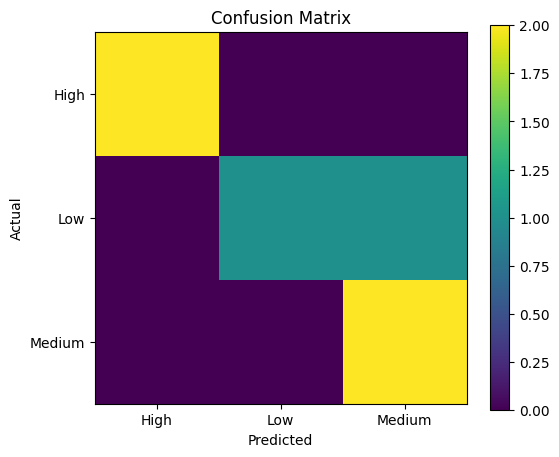

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    [0, 1, 2],
    ["High", "Low", "Medium"]
)

plt.yticks(
    [0, 1, 2],
    ["High", "Low", "Medium"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
def predict_flood_risk(
    rainfall,
    temperature,
    humidity,
    water_level,
    soil_moisture,
    wind_speed
):

    new_data = pd.DataFrame([[
        rainfall,
        temperature,
        humidity,
        water_level,
        soil_moisture,
        wind_speed
    ]], columns=X.columns)

    new_data_scaled = scaler.transform(new_data)

    prediction = model.predict(new_data_scaled)[0]

    if prediction == "High":
        warning = "RED ALERT: High Flash Flood Risk! Take immediate safety measures."

    elif prediction == "Medium":
        warning = "YELLOW ALERT: Medium Flash Flood Risk. Stay alert and monitor conditions."

    else:
        warning = "GREEN ALERT: Low Flash Flood Risk. Normal conditions."

    return prediction, warning

In [ ]:
risk, warning = predict_flood_risk(
    150,
    26,
    82,
    2.8,
    60,
    14
)

print("Predicted Flood Risk:", risk)
print("Early Warning:", warning)

Predicted Flood Risk: High
Early Warning: RED ALERT: High Flash Flood Risk! Take immediate safety measures.


In [ ]:
risk, warning = predict_flood_risk(
    25,
    32,
    48,
    1.1,
    22,
    5
)

print("Predicted Flood Risk:", risk)
print("Early Warning:", warning)

Predicted Flood Risk: Low
Early Warning: GREEN ALERT: Low Flash Flood Risk. Normal conditions.


In [ ]:
risk, warning = predict_flood_risk(
    25,
    32,
    48,
    1.1,
    22,
    5
)

print("Predicted Flood Risk:", risk)
print("Early Warning:", warning)

Predicted Flood Risk: Low
Early Warning: GREEN ALERT: Low Flash Flood Risk. Normal conditions.
